In [43]:
import matplotlib.pyplot as plt
import numpy as np
from open_ephys.analysis import Session
import os
import re
from scipy.signal import butter, filtfilt, lfilter

# ==== Select Session ====
w = 1  # recordnode index

# ==== Define Filters ====

def bandpass_filter(data, fs, lowcut=100, highcut=1000, order=2):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return lfilter(b, a, data)

def full_filter(data, fs):
    return bandpass_filter(data, fs)

# ==== Load Session ====
directory = '2-24-2026/SEQ-04_Config1_Test1_2026-02-24_13-50-17_004'
session = Session(directory)
print('Pass Initial Test, Moving on to Loading Session...\n')


Pass Initial Test, Moving on to Loading Session...




EXPERIMENT1, Recording 1
Open Ephys GUI Recording
ID: 0x1d16d314590
Format: Binary
Directory: 2-24-2026/SEQ-04_Config1_Test1_2026-02-24_13-50-17_004\Record Node 111\experiment1\recording1
Experiment Index: 0
Recording Index: 0
Channels: ['CH1', 'CH5', 'CH7', 'CH8', 'CH10', 'CH12', 'ADC1'] 

Loaded 950 MessageCenter entries
[Time: 269.399800 s] Message: Recording 1: Configuration 1 - CH5 (Red), CH7 (Green), CH10 (Black); Ramp start at 0.10 mA; in steps of 0.05 mA; end ramp at 3.00 mA
[Time: 285.078200 s] Message: Starting at 0.10 mA
[Time: 291.311200 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 295.326400 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 299.341600 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 303.318600 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 307.333800 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 311.310600 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 315.325800 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 317.008400 s] Message: Starting at 0.15 mA
[Time: 319.3

C:\Users\dal866445\AppData\Local\Temp\ipykernel_70592\2175693827.py:59: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


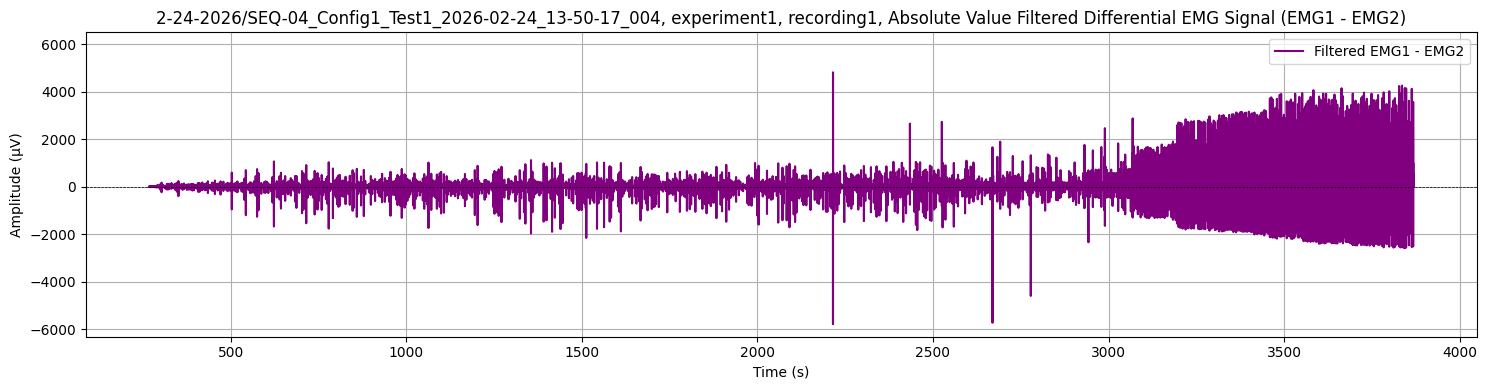

In [45]:
x = 0
exp = "experiment1"
y = f"recording{x + 1}"
v = f"Record Node 106" if w == 0 else f"Record Node 111"

try:
    recording = session.recordnodes[w].recordings[x]
except IndexError:
    print(f"No recording {x+1} found in {exp}")
    
print(f"\n{exp.upper()}, Recording {x+1}")
print(recording)

if not any(sync.get("main", False) for sync in recording.sync_lines):
    recording.add_sync_line(1, 100, 'Rhythm Data', main=True)

metadata = recording.continuous[0].metadata
channel_names = metadata.channel_names
print("Channels:", channel_names, '\n')

stream = recording.continuous[0]
timestamps = stream.timestamps
n_timestamps = timestamps.shape[0]
data = stream.get_samples(start_sample_index=0, end_sample_index=n_timestamps)
sample_rate = metadata.sample_rate

emg1_raw = data[:, 2]
emg2_raw = data[:, 3]
adc1 = np.abs(data[:, 6])
differential_emg = full_filter(emg2_raw - emg1_raw, sample_rate)

events = recording.events
sync_events = events[(events.line == 1) & (events.processor_id == 100) &
                        (events.stream_name == 'Rhythm Data') & (events.state == 1)]
sync_timestamps = sync_events['timestamp'].to_numpy()

messagecenter_dir = os.path.join(directory, v, exp, y, "events", "MessageCenter")
if not os.path.exists(messagecenter_dir):
    print(f"MessageCenter directory not found for {exp}/{y}")
   
texts = np.load(os.path.join(messagecenter_dir, "text.npy"), allow_pickle=True)
timestamps_msg = np.load(os.path.join(messagecenter_dir, "timestamps.npy"))
decoded_texts = [t.decode('utf-8') if isinstance(t, bytes) else str(t) for t in texts]
message_entries = list(zip(timestamps_msg, decoded_texts))
print(f"Loaded {len(decoded_texts)} MessageCenter entries")

for text, time in zip(decoded_texts, timestamps_msg):
    print(f"[Time: {time:.6f} s] Message: {text}")

plt.figure(figsize=(15, 4))
plt.plot(timestamps, differential_emg, label="Filtered EMG1 - EMG2", color='purple')
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.title(f"{directory}, {exp}, {y}, Absolute Value Filtered Differential EMG Signal (EMG1 - EMG2)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (μV)")
plt.grid(True)
plt.legend()
plt.ylim(top=6500)
plt.tight_layout()
plt.show()

In [46]:
# ==== Peri-Stimulus Analysis w/ Calculated Stim Start ====
pre_event_time = 5   # ms before stim start
post_event_time = 20 # ms after stim start
stim_threshold = 0.1 # ADC1 threshold
offstim_threshold = 3

# Pre-compute sample counts consistently to avoid off-by-one from float rounding
pre_samples  = int(round((pre_event_time  / 1000) * sample_rate))
post_samples = int(round((post_event_time / 1000) * sample_rate))
time_ms = np.linspace(-pre_event_time, post_event_time, pre_samples + post_samples)

peri_stim_segments_emg = []
peri_stim_segments_adc1 = []
segment_stim_start_times = []
segment_stim_end_times = []
segment_stim_center_times = []


In [47]:

for stamp in sync_timestamps:
    idx_start = np.searchsorted(timestamps, stamp)
    idx_end   = np.searchsorted(timestamps, stamp + 0.010)
    idx_center = (idx_start + idx_end) / 2

    if idx_start < 0 or idx_end > len(timestamps):
        continue

    adc1_seg = adc1[idx_start:idx_end]
    time_seg = timestamps[idx_start:idx_end]

    above_idxs = np.where(adc1_seg > stim_threshold)[0]
    if len(above_idxs) == 0:
        continue

    stim_start_idx = idx_start + above_idxs[0]
    stim_start_time = timestamps[stim_start_idx]

    idx_pre  = stim_start_idx - pre_samples
    idx_post = stim_start_idx + post_samples

    if idx_pre < 0 or idx_post > len(timestamps):
        continue

    time_window = timestamps[idx_pre:idx_post]
    time_zeroed = time_window - stim_start_time

    seg_emg  = differential_emg[idx_pre:idx_post]
    seg_adc1 = adc1[idx_pre:idx_post]

    # Determine stim end
    post_mask = (time_zeroed >= 0)
    adc1_post = seg_adc1[post_mask]
    time_post = time_zeroed[post_mask]
    below_idxs = np.where(adc1_post < offstim_threshold)[0]

    stim_end_time = (time_post[below_idxs[0]] * 1000 if len(below_idxs) > 0 else post_event_time)

    peri_stim_segments_emg.append(seg_emg)
    peri_stim_segments_adc1.append(seg_adc1)
    segment_stim_start_times.append(stim_start_time)
    segment_stim_end_times.append(stim_end_time)


In [48]:
print(time_window)
print(idx_center)
print(idx_start)
print(idx_end)
print(post_event_time)
print(stim_end_time)
type(stim_end_time)


[3867.371  3867.3712 3867.3714 3867.3716 3867.3718 3867.372  3867.3722
 3867.3724 3867.3726 3867.3728 3867.373  3867.3732 3867.3734 3867.3736
 3867.3738 3867.374  3867.3742 3867.3744 3867.3746 3867.3748 3867.375
 3867.3752 3867.3754 3867.3756 3867.3758 3867.376  3867.3762 3867.3764
 3867.3766 3867.3768 3867.377  3867.3772 3867.3774 3867.3776 3867.3778
 3867.378  3867.3782 3867.3784 3867.3786 3867.3788 3867.379  3867.3792
 3867.3794 3867.3796 3867.3798 3867.38   3867.3802 3867.3804 3867.3806
 3867.3808 3867.381  3867.3812 3867.3814 3867.3816 3867.3818 3867.382
 3867.3822 3867.3824 3867.3826 3867.3828 3867.383  3867.3832 3867.3834
 3867.3836 3867.3838 3867.384  3867.3842 3867.3844 3867.3846 3867.3848
 3867.385  3867.3852 3867.3854 3867.3856 3867.3858 3867.386  3867.3862
 3867.3864 3867.3866 3867.3868 3867.387  3867.3872 3867.3874 3867.3876
 3867.3878 3867.388  3867.3882 3867.3884 3867.3886 3867.3888 3867.389
 3867.3892 3867.3894 3867.3896 3867.3898 3867.39   3867.3902 3867.3904
 3867.390

numpy.float64

In [49]:
# ==== Dynamically determine stimulation groups ====
trigger_pattern = re.compile(r"RHDCONTROL TRIGGER")
stim_pattern = re.compile(r"starting(?: at)? (\d+\.?\d*)\s*mA", re.IGNORECASE)

stim_groups = []
current_group = []
current_amp = None

for t, msg in message_entries:
    if stim_pattern.search(msg):
        if current_amp is not None and current_group:
            stim_groups.append((current_amp, current_group))
        current_amp = float(stim_pattern.search(msg).group(1))
        current_group = []
    elif trigger_pattern.search(msg):
        if current_amp is not None:
            current_group.append(t)

if current_amp is not None and current_group:
    stim_groups.append((current_amp, current_group))

In [50]:
# time_ms is now computed in the parameters cell above alongside pre_samples / post_samples
print(f"time_ms shape: {time_ms.shape}, pre_samples: {pre_samples}, post_samples: {post_samples}")


time_ms shape: (125,), pre_samples: 25, post_samples: 100


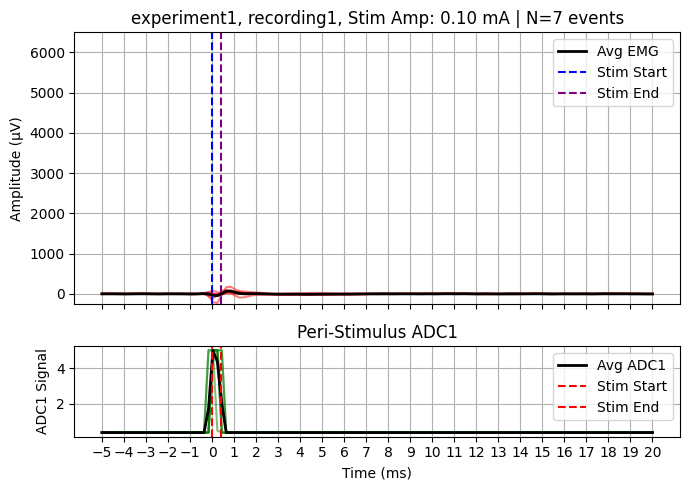

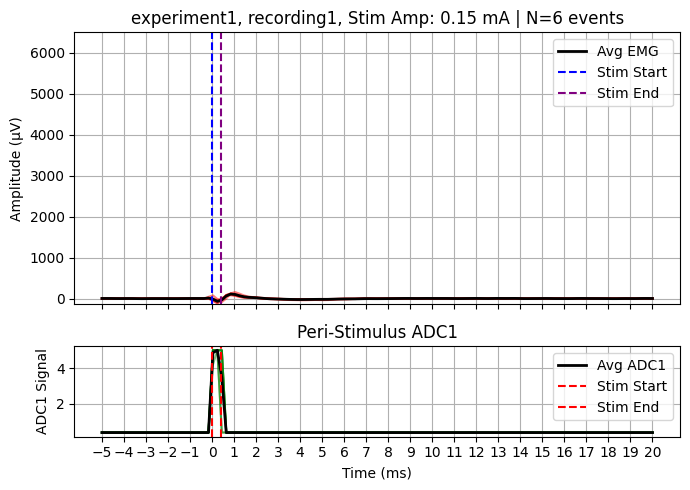

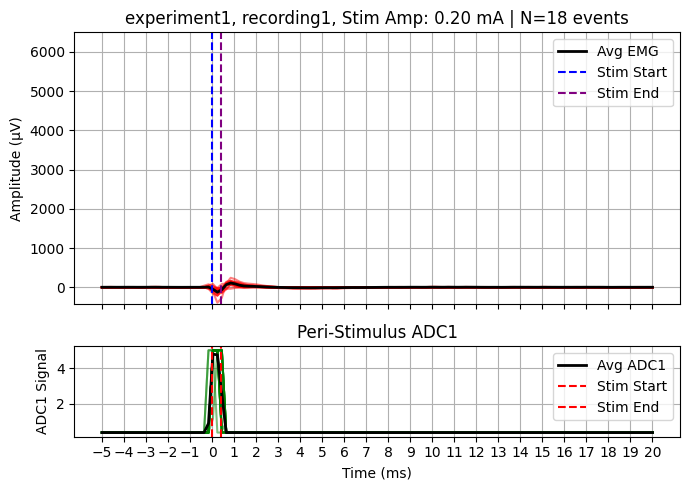

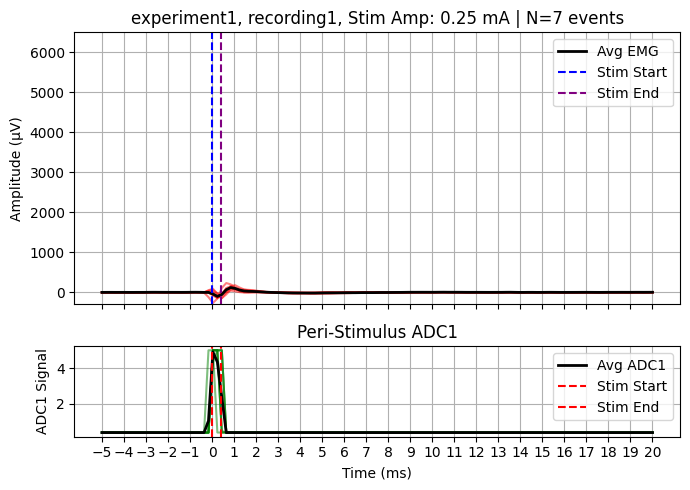

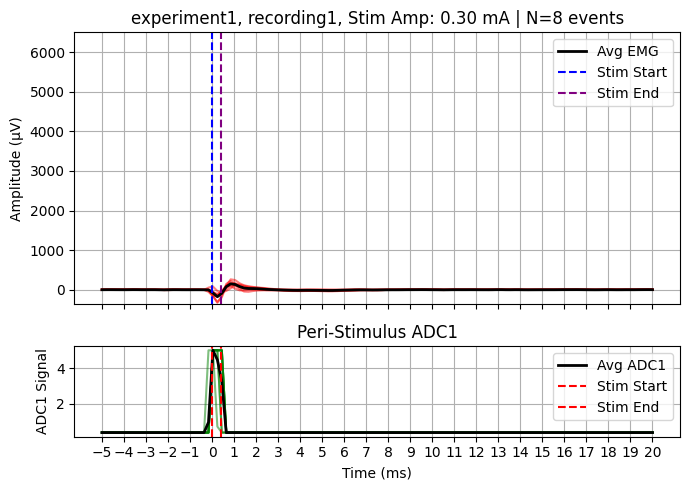

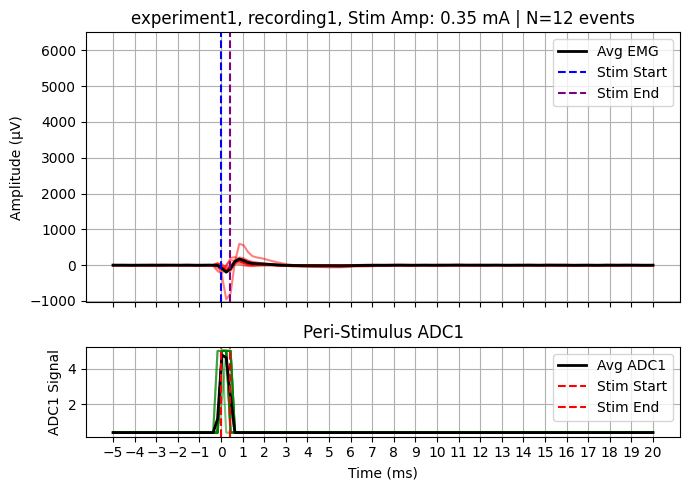

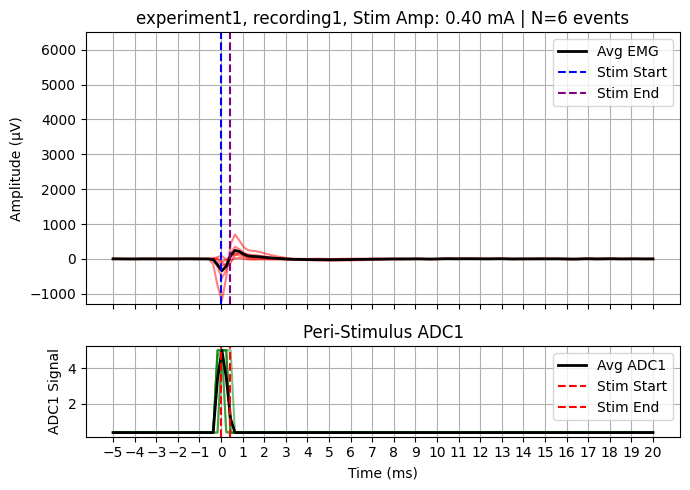

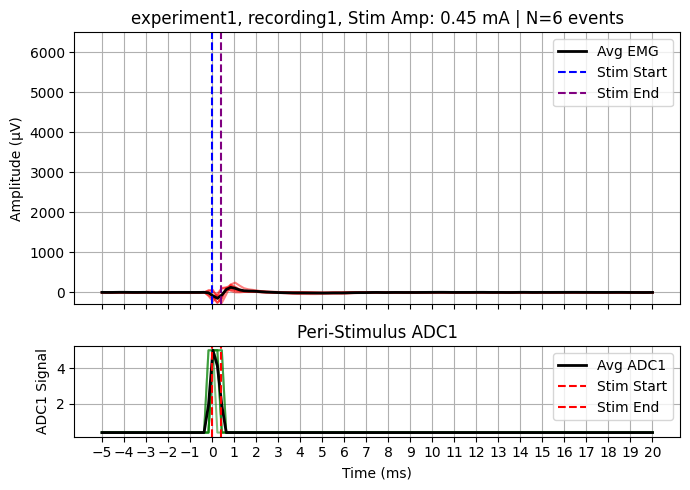

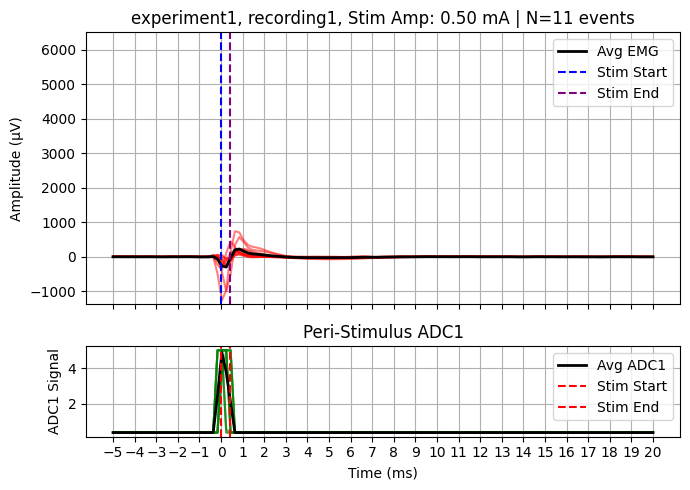

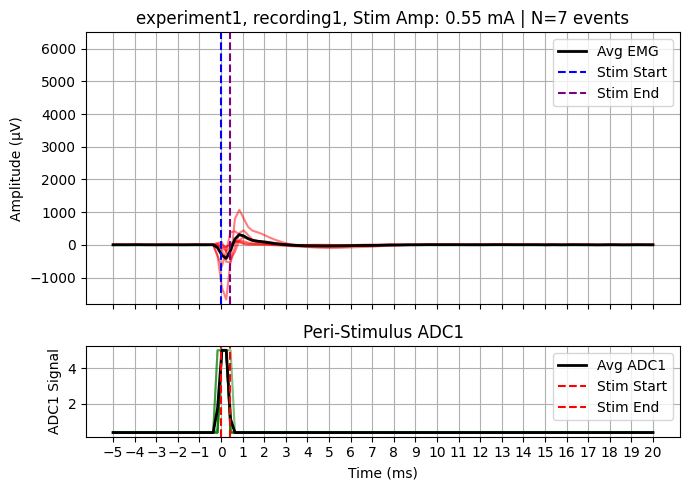

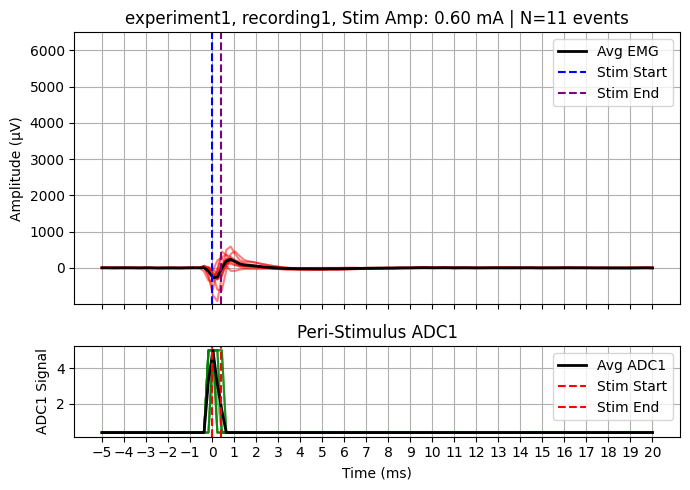

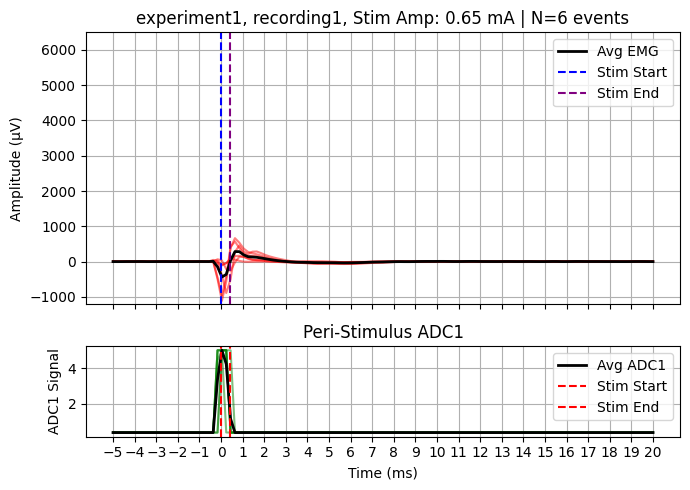

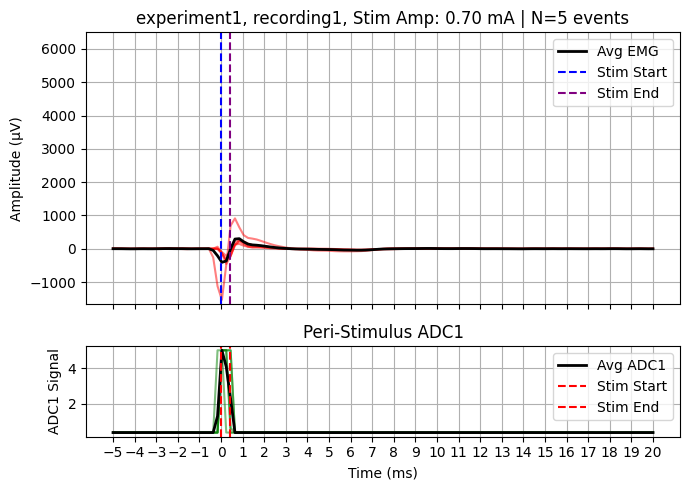

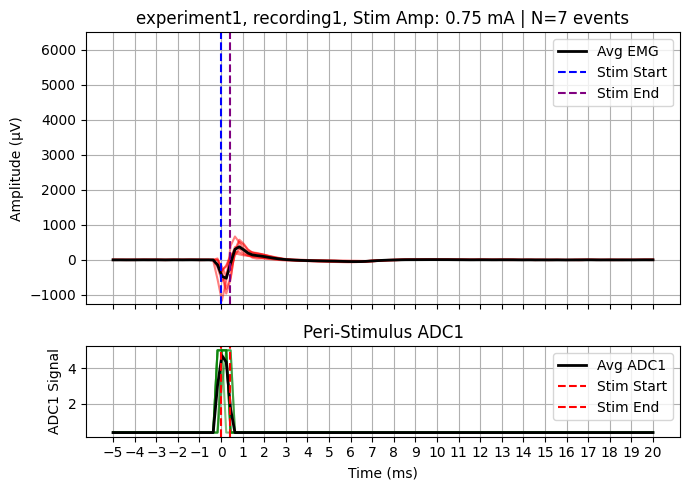

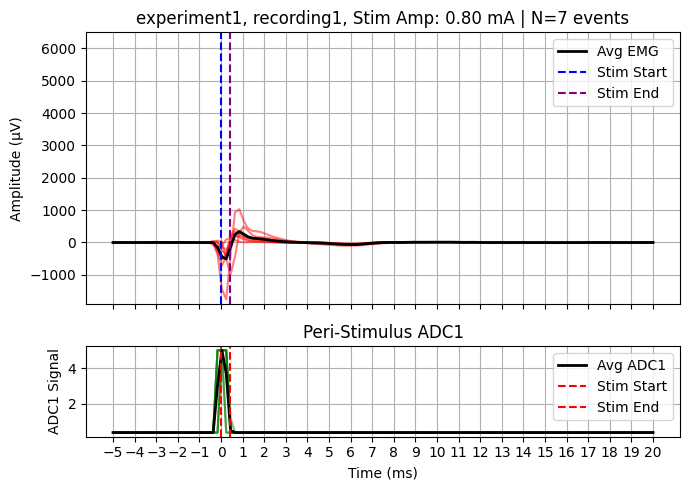

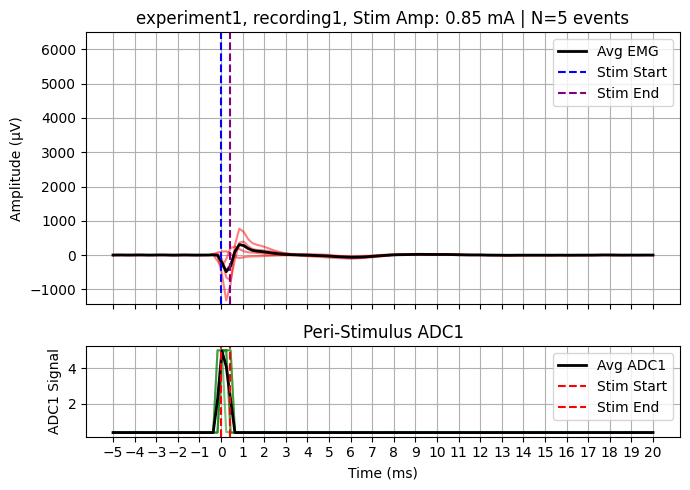

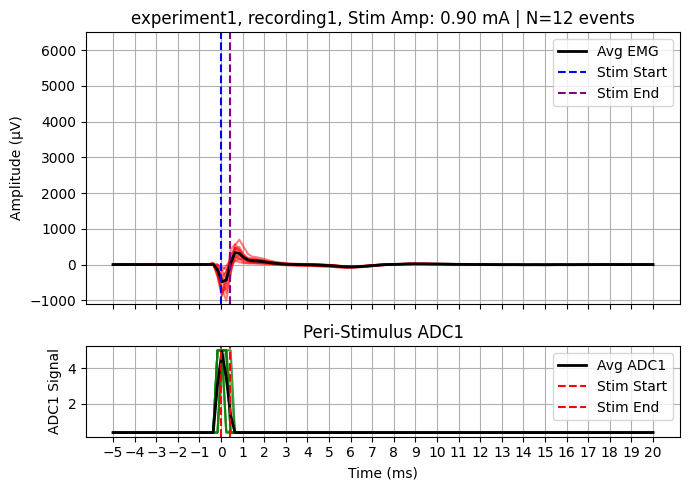

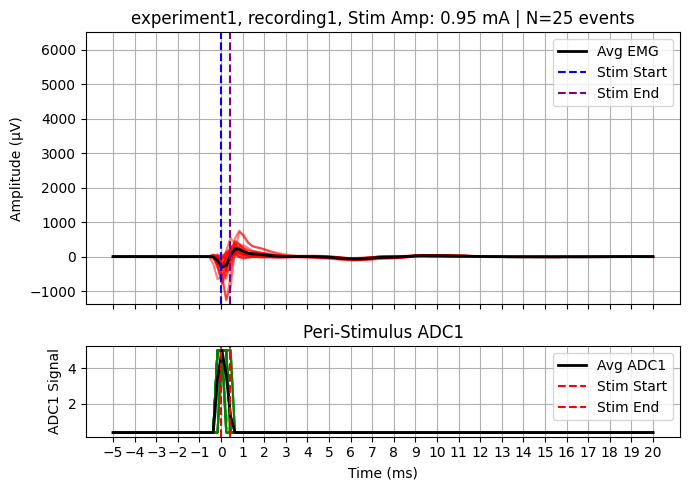

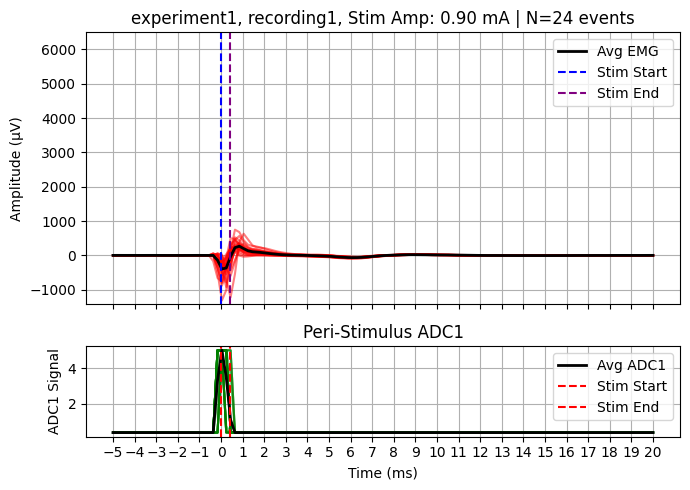

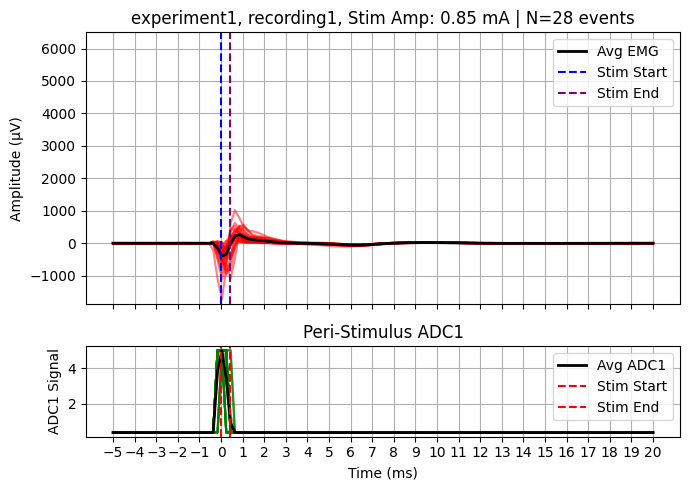

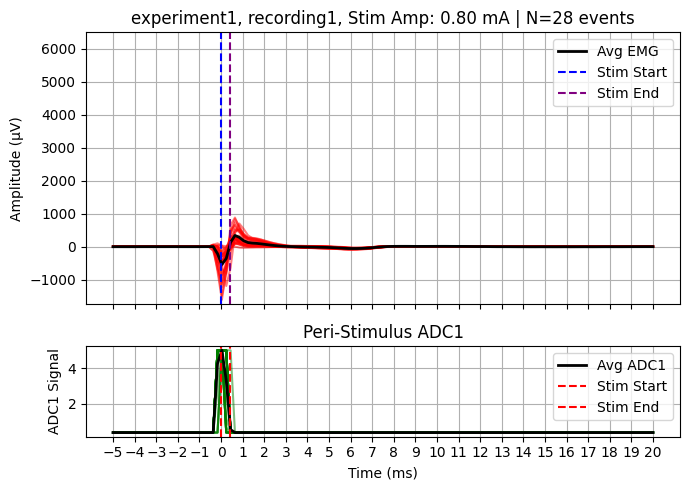

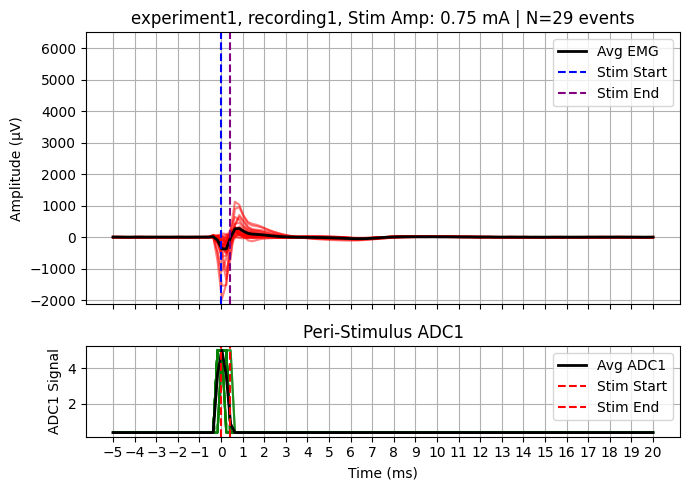

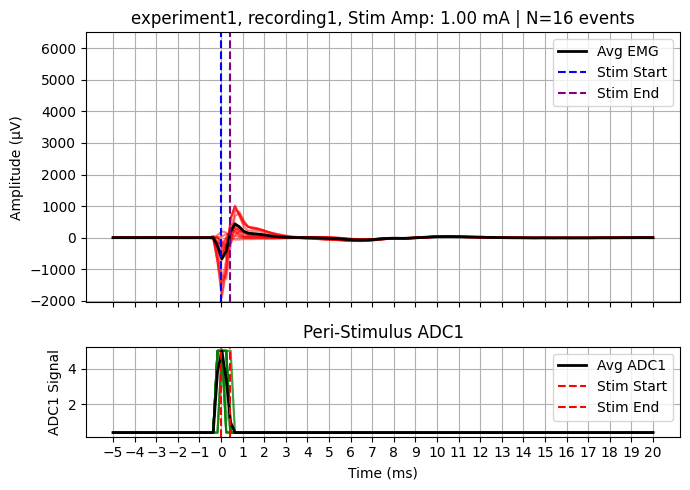

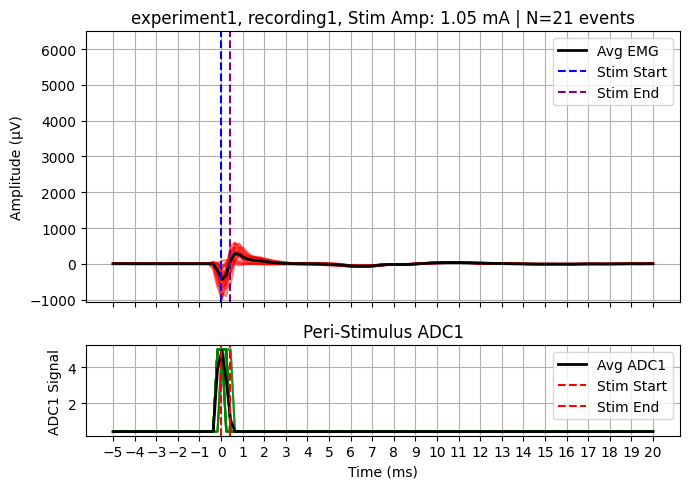

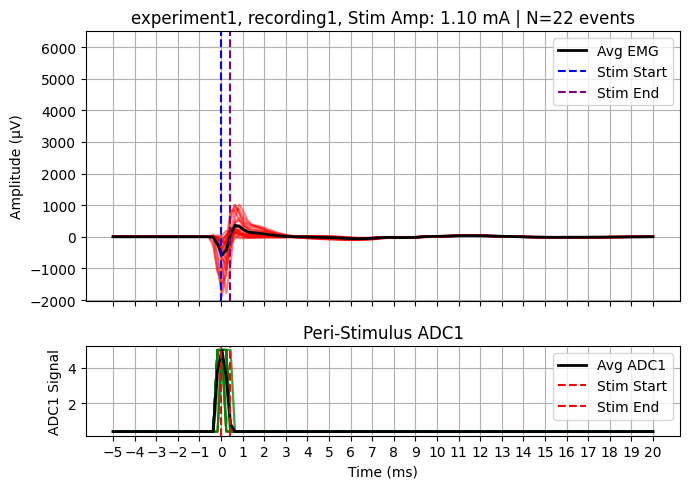

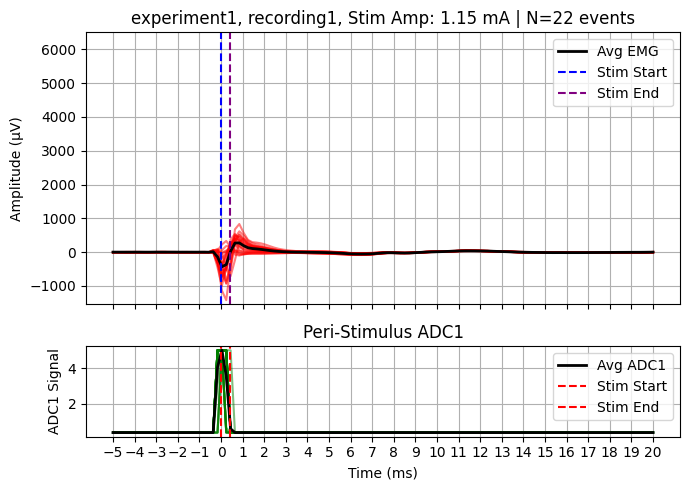

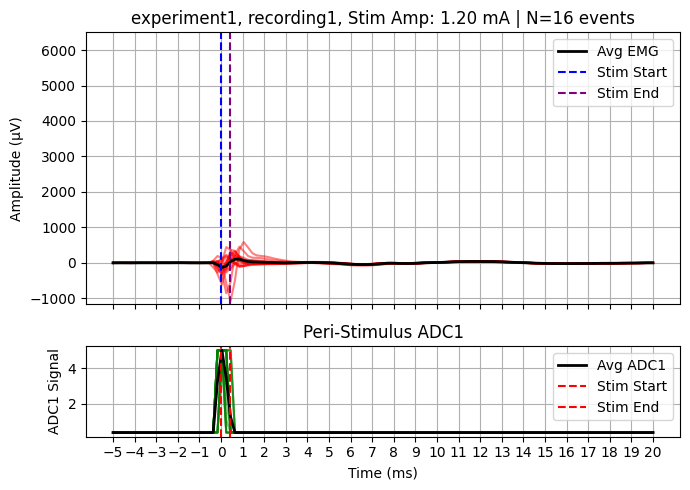

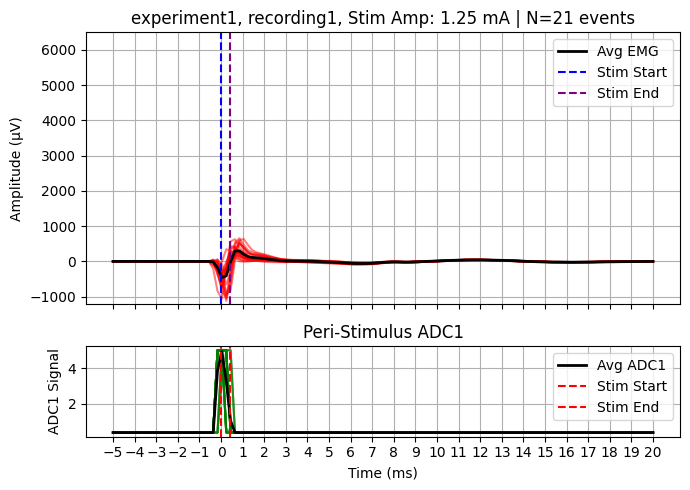

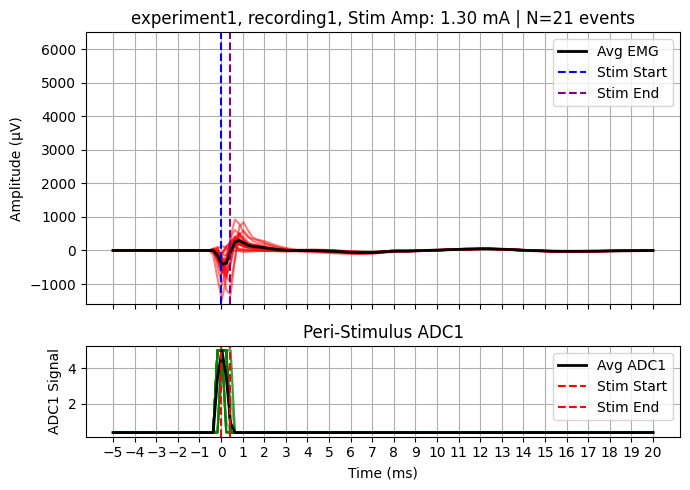

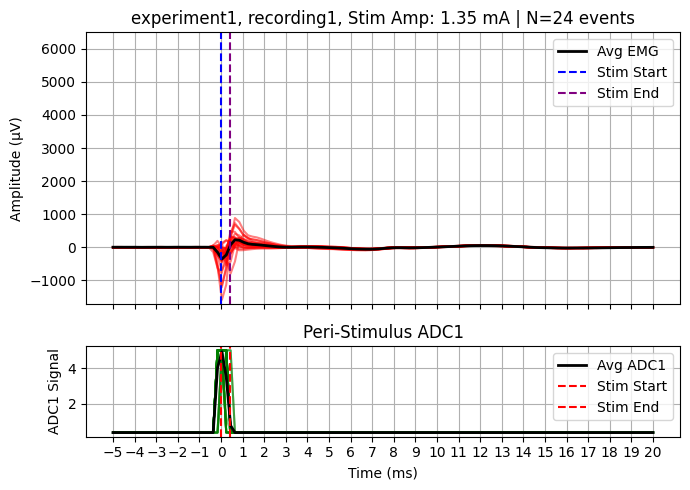

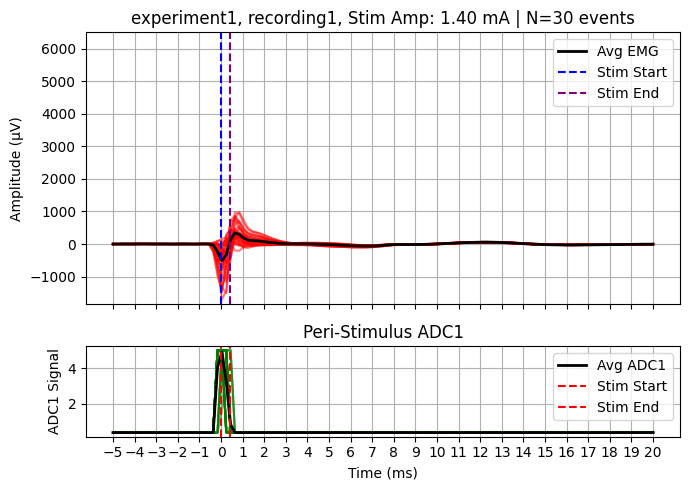

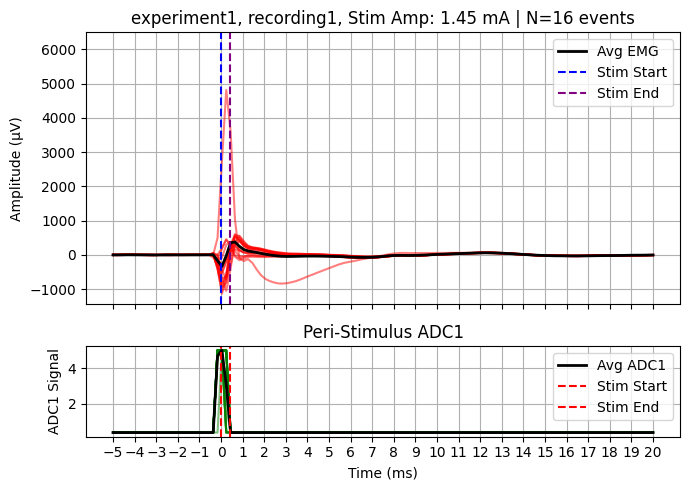

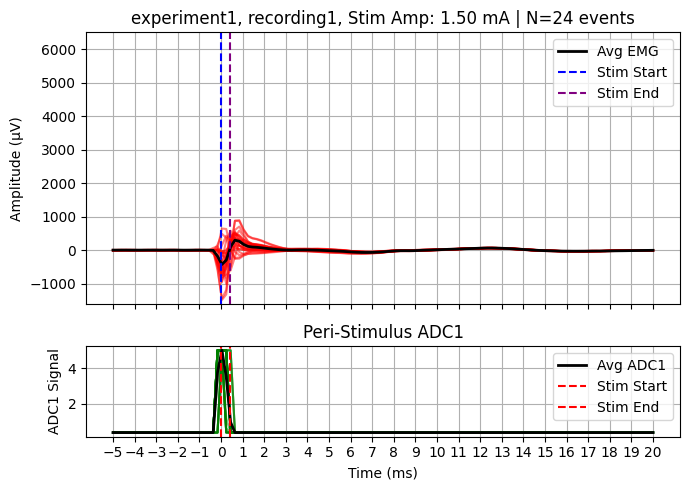

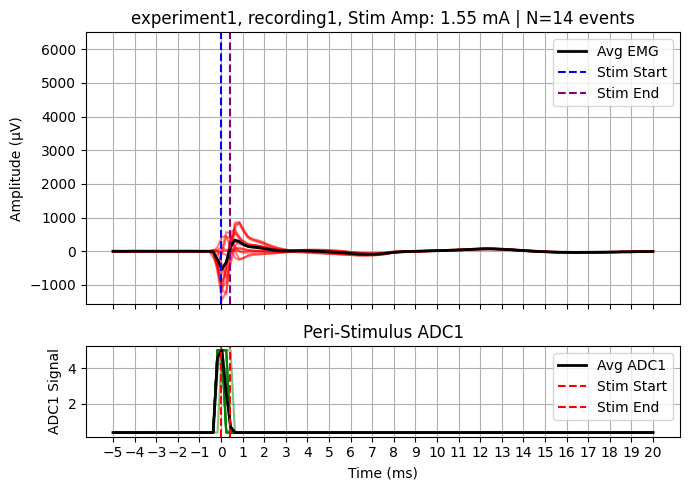

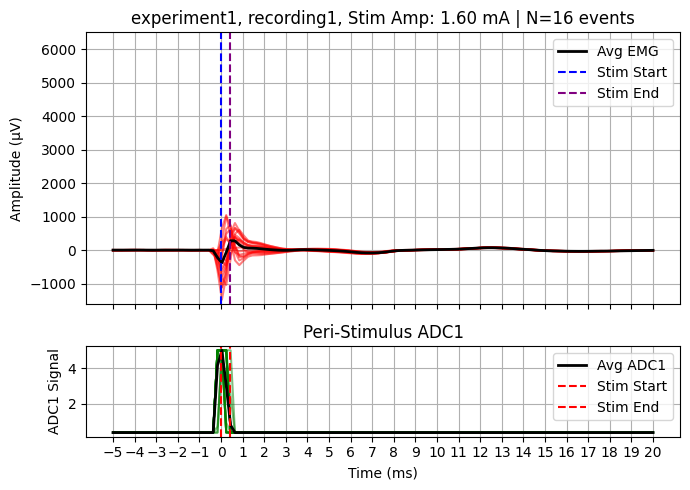

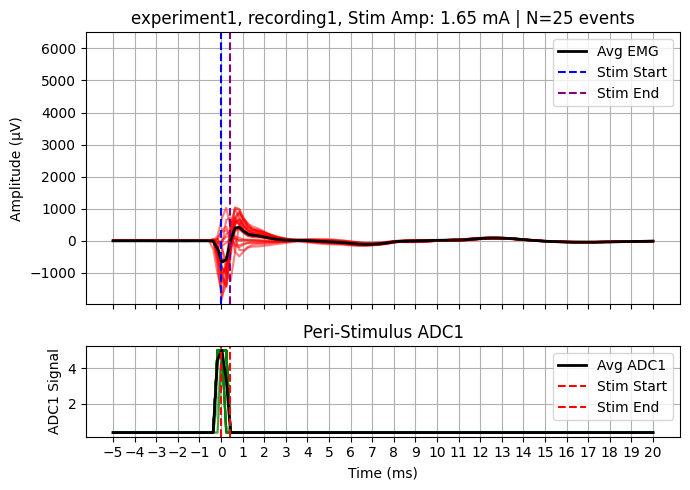

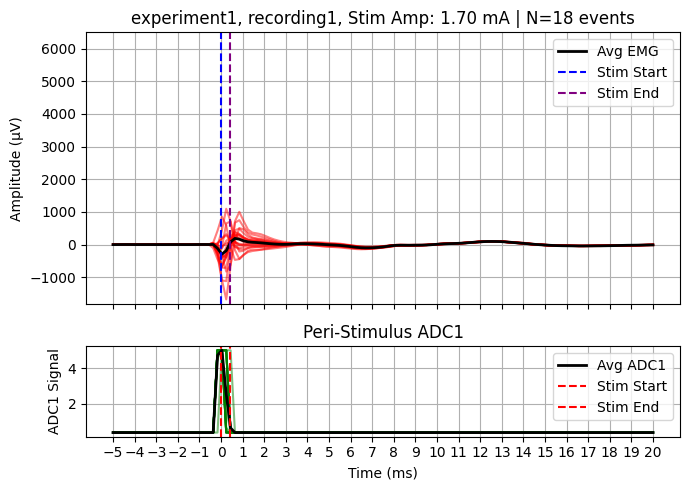

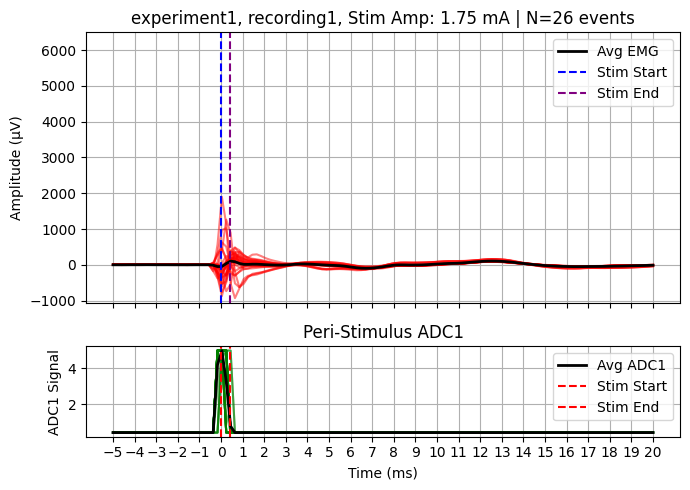

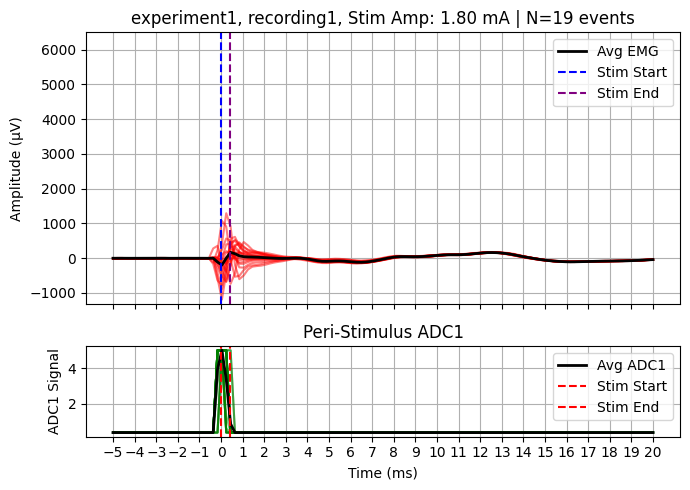

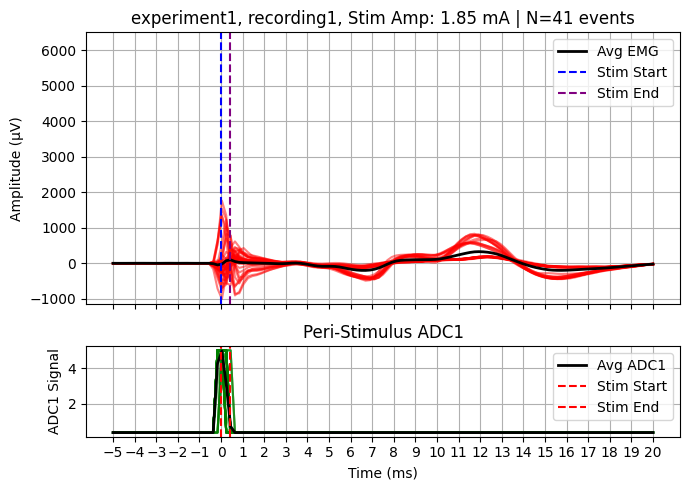

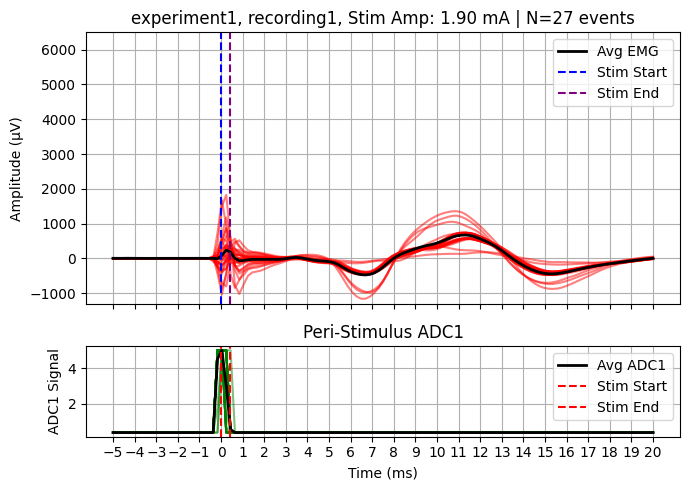

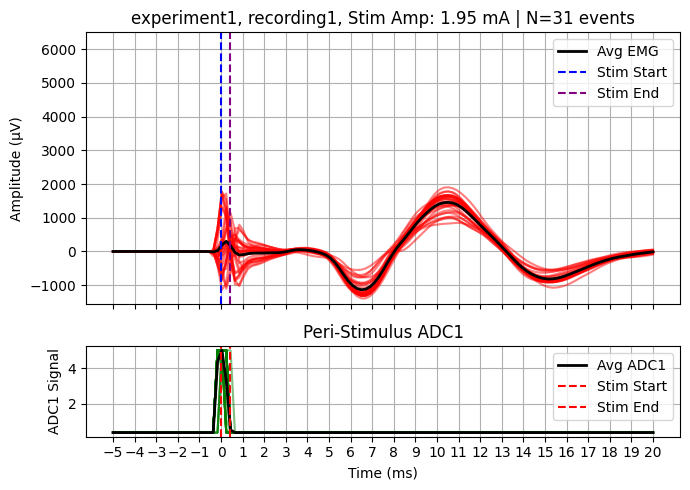

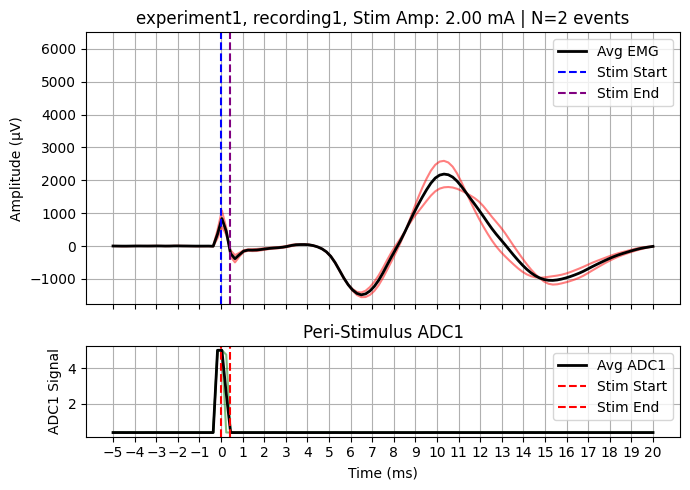

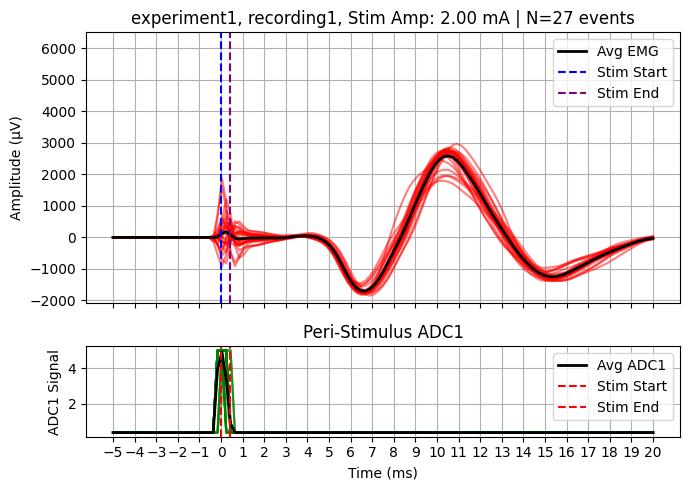

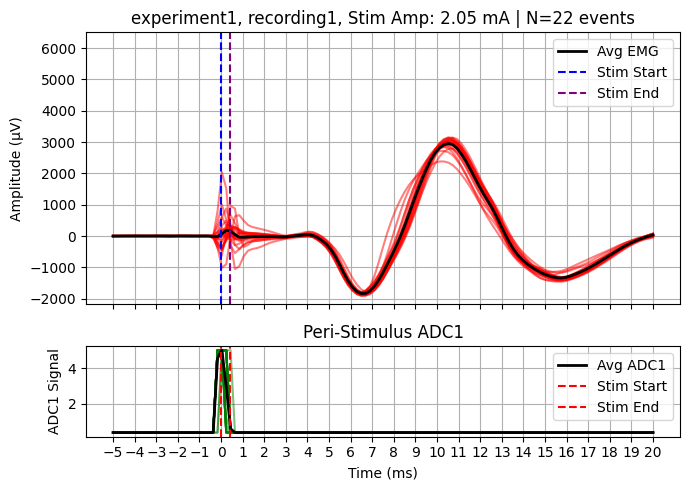

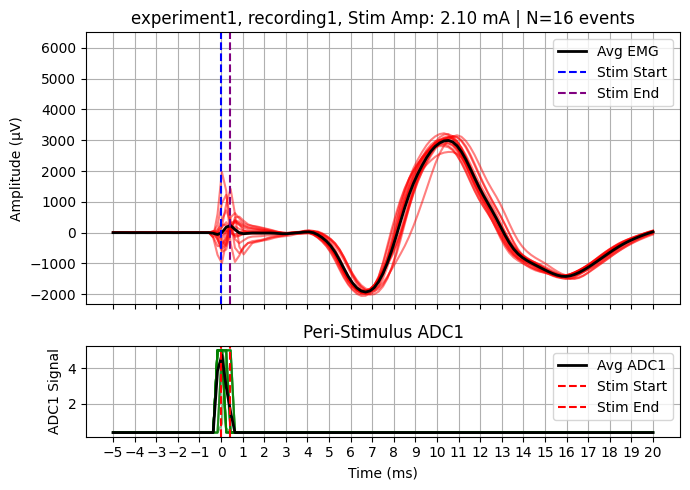

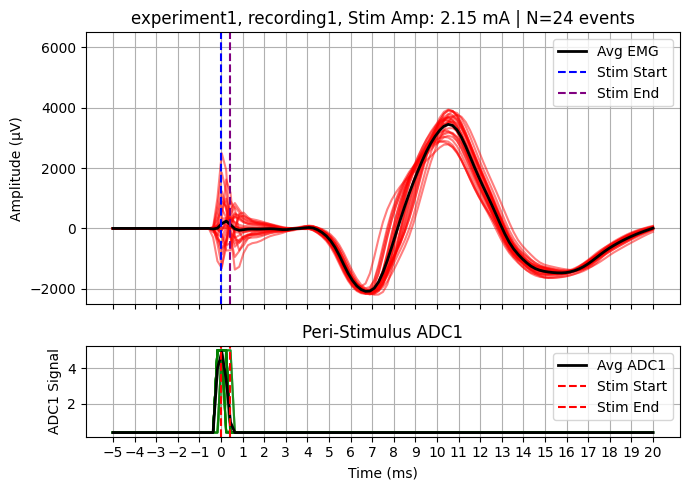

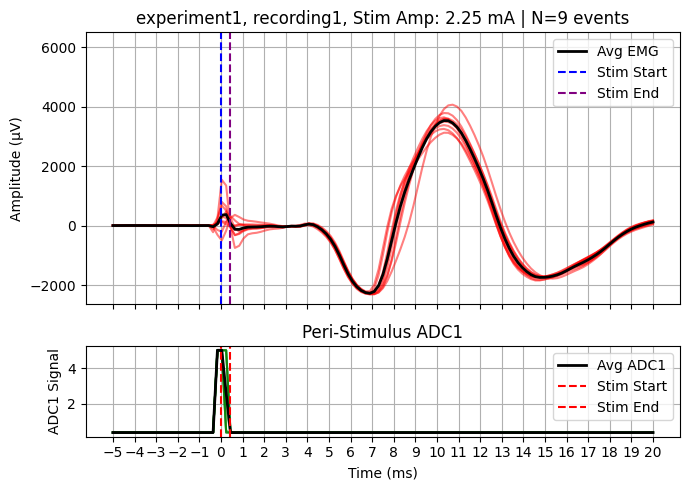

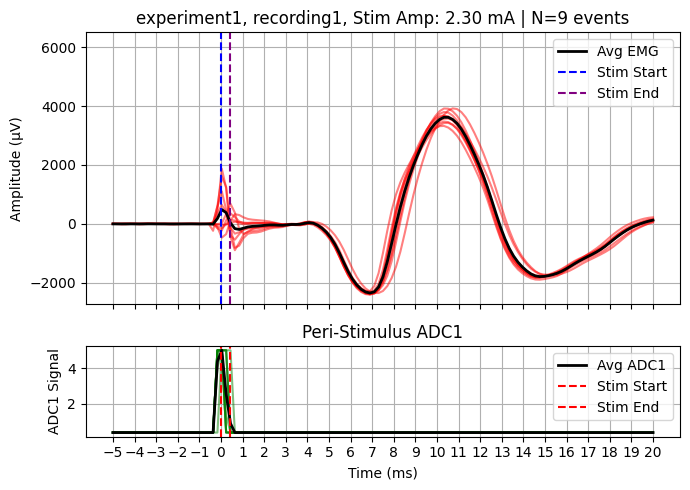

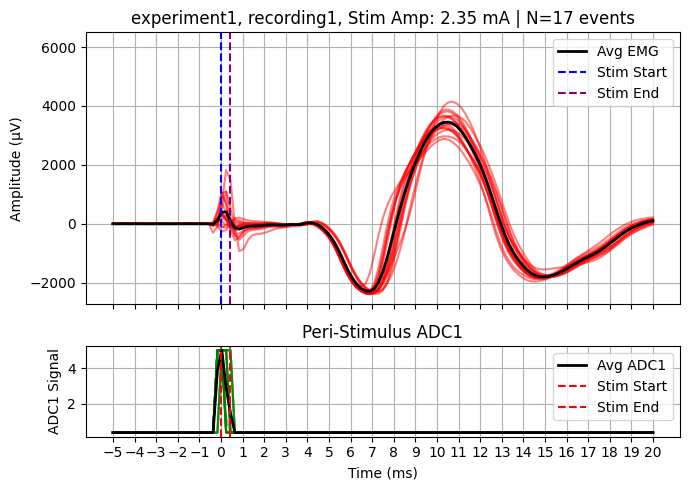

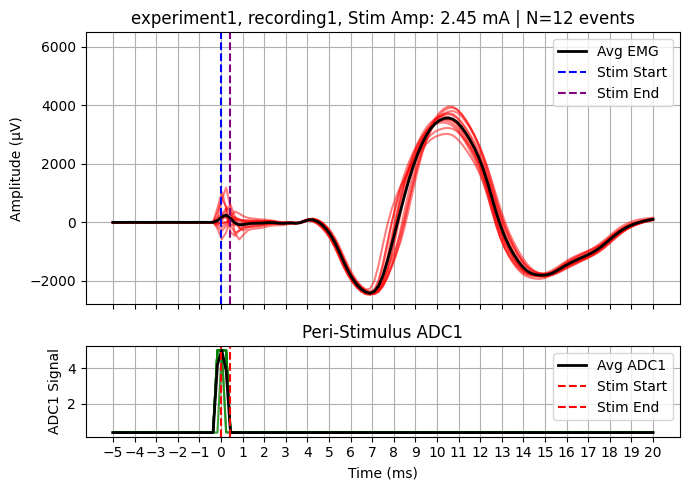

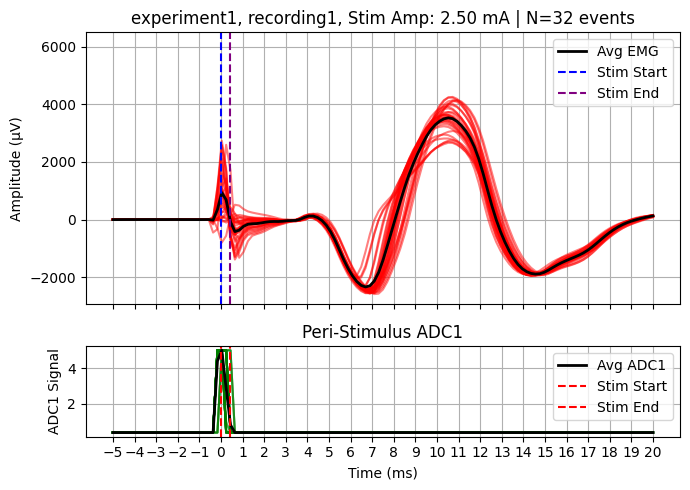

In [51]:

#stim_amp, trigger_times_group = stim_groups[0]
for stim_amp, trigger_times_group in stim_groups:
    group_emg = []
    group_adc1 = []
    group_end_times = []
    group_start_times = []

    for trig_time in trigger_times_group:
        idx_match = np.argmin(np.abs(np.array(segment_stim_start_times) - trig_time))
        if abs(segment_stim_start_times[idx_match] - trig_time) < 0.1:
            group_emg.append(peri_stim_segments_emg[idx_match])
            group_adc1.append(peri_stim_segments_adc1[idx_match])
            group_end_times.append(segment_stim_end_times[idx_match])
            group_start_times.append(segment_stim_start_times[idx_match])

    if not group_emg:
        continue

    avg_emg  = np.mean(group_emg, axis=0)
    avg_adc1 = np.mean(group_adc1, axis=0)
    #avg_end_time = np.mean(group_end_times)
    avg_end_time = np.mean(segment_stim_end_times)  # ms after stim start

    fig, axs = plt.subplots(2, 1, figsize=(7, 5), sharex=True, gridspec_kw={'height_ratios':[3,1]})

    for trace in group_emg:
        axs[0].plot(time_ms, trace, color='red', alpha=0.5)
    axs[0].plot(time_ms, avg_emg, color='black', linewidth=2, label='Avg EMG')
    axs[0].axvline(0, color='blue', linestyle='--', label='Stim Start')
    axs[0].axvline(stim_end_time, color='purple', linestyle='--', label='Stim End')
    axs[0].set_title(f"{exp}, {y}, Stim Amp: {stim_amp:.2f} mA | N={len(group_emg)} events")
    axs[0].set_ylabel("Amplitude (μV)")
    axs[0].legend()
    axs[0].grid(True)
    axs[0].set_ylim(top=6500)

    for trace in group_adc1:
        axs[1].plot(time_ms, trace, color='green', alpha=0.5)
    axs[1].plot(time_ms, avg_adc1, color='black', linewidth=2, label='Avg ADC1')
    axs[1].axvline(0, color='red', linestyle='--', label='Stim Start')
    axs[1].axvline(stim_end_time, color='red', linestyle='--', label='Stim End')
    axs[1].set_title("Peri-Stimulus ADC1")
    axs[1].set_xlabel("Time (ms)")
    axs[1].set_ylabel("ADC1 Signal")
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_xticks(np.arange(int(time_ms[0]), int(time_ms[-1])+1, 1))

    plt.tight_layout()
    plt.show()
    